<a href="https://colab.research.google.com/github/Abdulkhabeer70/Face_Mask_Detection/blob/main/03_Transfer_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 3: Transfer Learning — MobileNetV2 & ResNet50

### Why Transfer Learning?
Instead of training from scratch (like our Custom CNN), we reuse networks already trained on **ImageNet (1.4M images)**. The early layers already know edges, textures, and shapes — we just need to teach the top layers about masks.

### Two-Phase Training Strategy
- **Phase 1**: Freeze the base, train only our classifier head (10 epochs, lr=0.001)
- **Phase 2**: Unfreeze top layers, fine-tune with small lr (30 epochs, lr=0.0001)

### Memory Note
We train MobileNetV2 first, **delete it from memory**, then train ResNet50. This prevents RAM crashes on free Colab.

---

In [1]:
# ============================================================
# 1. Setup
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import os, gc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2, ResNet50
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import Sequence
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

np.random.seed(42)
tf.random.set_seed(42)
sns.set_style('whitegrid')

PROJECT_DIR = '/content/drive/MyDrive/Face_Mask_Detection'
DATA_DIR = os.path.join(PROJECT_DIR, 'data')
MODEL_DIR = os.path.join(PROJECT_DIR, 'models')
os.makedirs(MODEL_DIR, exist_ok=True)

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")
print(f"Data: {DATA_DIR}")

Mounted at /content/drive
TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Data: /content/drive/MyDrive/Face_Mask_Detection/data


In [2]:
# ============================================================
# 1.2 Load Data
# ============================================================
print("Loading data from Google Drive...")
X_train = np.load(os.path.join(DATA_DIR, 'X_train.npy'))
y_train = np.load(os.path.join(DATA_DIR, 'y_train.npy'))
X_val   = np.load(os.path.join(DATA_DIR, 'X_val.npy'))
y_val   = np.load(os.path.join(DATA_DIR, 'y_val.npy'))
X_test  = np.load(os.path.join(DATA_DIR, 'X_test.npy'))
y_test  = np.load(os.path.join(DATA_DIR, 'y_test.npy'))

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"RAM: {(X_train.nbytes+X_val.nbytes+X_test.nbytes)/(1024**3):.2f} GB")

CLASS_NAMES = ['No Mask', 'Mask']
BATCH_SIZE = 32

Loading data from Google Drive...
Train: (5287, 224, 224, 3) | Val: (1133, 224, 224, 3) | Test: (1133, 224, 224, 3)
RAM: 4.24 GB


In [3]:
# ============================================================
# 1.3 Memory-Safe Batch Generator
# ============================================================
class DataGen(Sequence):
    def __init__(self, X, y, batch_size=32, shuffle=True):
        self.X, self.y = X, y
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indices = np.arange(len(X))
        if shuffle: np.random.shuffle(self.indices)
    def __len__(self):
        return int(np.ceil(len(self.X) / self.batch_size))
    def __getitem__(self, idx):
        b = self.indices[idx*self.batch_size:(idx+1)*self.batch_size]
        return self.X[b], self.y[b]
    def on_epoch_end(self):
        if self.shuffle: np.random.shuffle(self.indices)

train_gen = DataGen(X_train, y_train, BATCH_SIZE)
val_gen   = DataGen(X_val, y_val, BATCH_SIZE, shuffle=False)
print(f"Generator ready: {len(train_gen)} train batches, {len(val_gen)} val batches")

Generator ready: 166 train batches, 36 val batches


In [4]:
# ============================================================
# 1.4 Helper Functions
# ============================================================
def plot_history(h1, h2, name):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'{name} Training History', fontsize=16, fontweight='bold')
    for i, (h, phase) in enumerate([(h1,'Phase 1: Head Only'), (h2,'Phase 2: Fine-Tune')]):
        axes[i,0].plot(h.history['accuracy'], 'b-o', ms=3, lw=2, label='Train')
        axes[i,0].plot(h.history['val_accuracy'], 'r-s', ms=3, lw=2, label='Val')
        axes[i,0].set_title(f'{phase} — Accuracy', fontweight='bold')
        axes[i,0].legend(); axes[i,0].grid(True, alpha=0.3)
        axes[i,1].plot(h.history['loss'], 'b-o', ms=3, lw=2, label='Train')
        axes[i,1].plot(h.history['val_loss'], 'r-s', ms=3, lw=2, label='Val')
        axes[i,1].set_title(f'{phase} — Loss', fontweight='bold')
        axes[i,1].legend(); axes[i,1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def eval_model(model, name):
    y_prob = model.predict(X_test, batch_size=32, verbose=1)
    y_pred = (y_prob > 0.5).astype(int).flatten()
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    print(f"\n{name} — Test Results")
    print(f"Accuracy: {acc*100:.2f}% | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")
    print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=4))
    fig, ax = plt.subplots(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                annot_kws={'size':14}, ax=ax)
    ax.set_title(f'{name} Confusion Matrix', fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    plt.tight_layout(); plt.show()
    return {'name':name, 'accuracy':acc, 'precision':prec, 'recall':rec, 'f1':f1, 'cm':cm}

print("Helpers ready.")

Helpers ready.


---
## Model A: MobileNetV2

**Lightweight** (~3.4M params) — designed for mobile/edge devices.
Uses depthwise separable convolutions and inverted residual blocks.

### Phase 1: Train head only (base frozen)

In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam

mobilenet_base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
mobilenet_base.trainable = False  # Freeze all

inputs = keras.Input(shape=(224,224,3))
x = mobilenet_base(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)
mobilenet_model = Model(inputs, outputs, name='MobileNetV2')

mobilenet_model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
mobilenet_model.summary()
print(f"\nBase frozen: {len(mobilenet_base.layers)} layers")

Model: "MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,586,177 (9.87 MB)

 Trainable params: 328,193 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)


Base frozen: 154 layers


In [7]:
# ============================================================
# MobileNetV2 — Phase 1 Training
# ============================================================
print("PHASE 1: Training head only (base frozen)...\n")

mb_h1 = mobilenet_model.fit(
    train_gen, epochs=10, validation_data=val_gen,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
    ], verbose=1
)
print(f"\nPhase 1 done — Best val_acc: {max(mb_h1.history['val_accuracy']):.4f}")

PHASE 1: Training head only (base frozen)...

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.9240 - loss: 0.1538

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


166/166 ━━━━━━━━━━━━━━━━━━━━ 58s 219ms/step - accuracy: 0.9654 - loss: 0.0819 - val_accuracy: 0.9929 - val_loss: 0.0274 - learning_rate: 0.0010
Epoch 2/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - accuracy: 0.9862 - loss: 0.0402 - val_accuracy: 0.9929 - val_loss: 0.0282 - learning_rate: 0.0010
Epoch 3/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.9905 - loss: 0.0253 - val_accuracy: 0.9921 - val_loss: 0.0304 - learning_rate: 0.0010
Epoch 4/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9935 - loss: 0.0150
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
166/166 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.9934 - loss: 0.0163 - val_accuracy: 0.9868 - val_loss: 0.0341 - learning_rate: 0.0010
Epoch 5/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - accuracy: 0.9970 - loss: 0.0097 - val_accuracy: 0.9885 - val_loss: 0.0352 - learning_rate: 5.0000e-04
Epoch 6/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.9975 - loss: 0.0077 -

### Phase 2: Unfreeze top 30 layers, fine-tune with lr=0.0001

In [8]:
# ============================================================
# MobileNetV2 — Phase 2: Fine-tune
# ============================================================
mobilenet_base.trainable = True
for layer in mobilenet_base.layers[:-30]:
    layer.trainable = False

mobilenet_model.compile(optimizer=Adam(learning_rate=0.0001),
                        loss='binary_crossentropy', metrics=['accuracy'])

trainable = sum(1 for l in mobilenet_base.layers if l.trainable)
print(f"Unfrozen top {trainable} layers, lr=0.0001")

mb_save = os.path.join(MODEL_DIR, 'mobilenetv2.keras')

print("\nPHASE 2: Fine-tuning...\n")
mb_h2 = mobilenet_model.fit(
    train_gen, epochs=30, validation_data=val_gen,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
        ModelCheckpoint(mb_save, monitor='val_accuracy', save_best_only=True, verbose=1)
    ], verbose=1
)
print(f"\nPhase 2 done — Best val_acc: {max(mb_h2.history['val_accuracy']):.4f}")

Unfrozen top 30 layers, lr=0.0001

PHASE 2: Fine-tuning...

Epoch 1/30
165/166 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.9606 - loss: 0.1040
Epoch 1: val_accuracy improved from None to 0.99382, saving model to /content/drive/MyDrive/Face_Mask_Detection/models/mobilenetv2.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Face_Mask_Detection/models/mobilenetv2.keras
166/166 ━━━━━━━━━━━━━━━━━━━━ 46s 159ms/step - accuracy: 0.9784 - loss: 0.0625 - val_accuracy: 0.9938 - val_loss: 0.0202 - learning_rate: 1.0000e-04
Epoch 2/30
165/166 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9926 - loss: 0.0199
Epoch 2: val_accuracy improved from 0.99382 to 0.99647, saving model to /content/drive/MyDrive/Face_Mask_Detection/models/mobilenetv2.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Face_Mask_Detection/models/mobilenetv2.keras
166/166 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - accuracy: 0.9930 - loss: 0.0221 - val_accuracy: 0.9965 - val_loss: 0.0207 - learning_rate: 

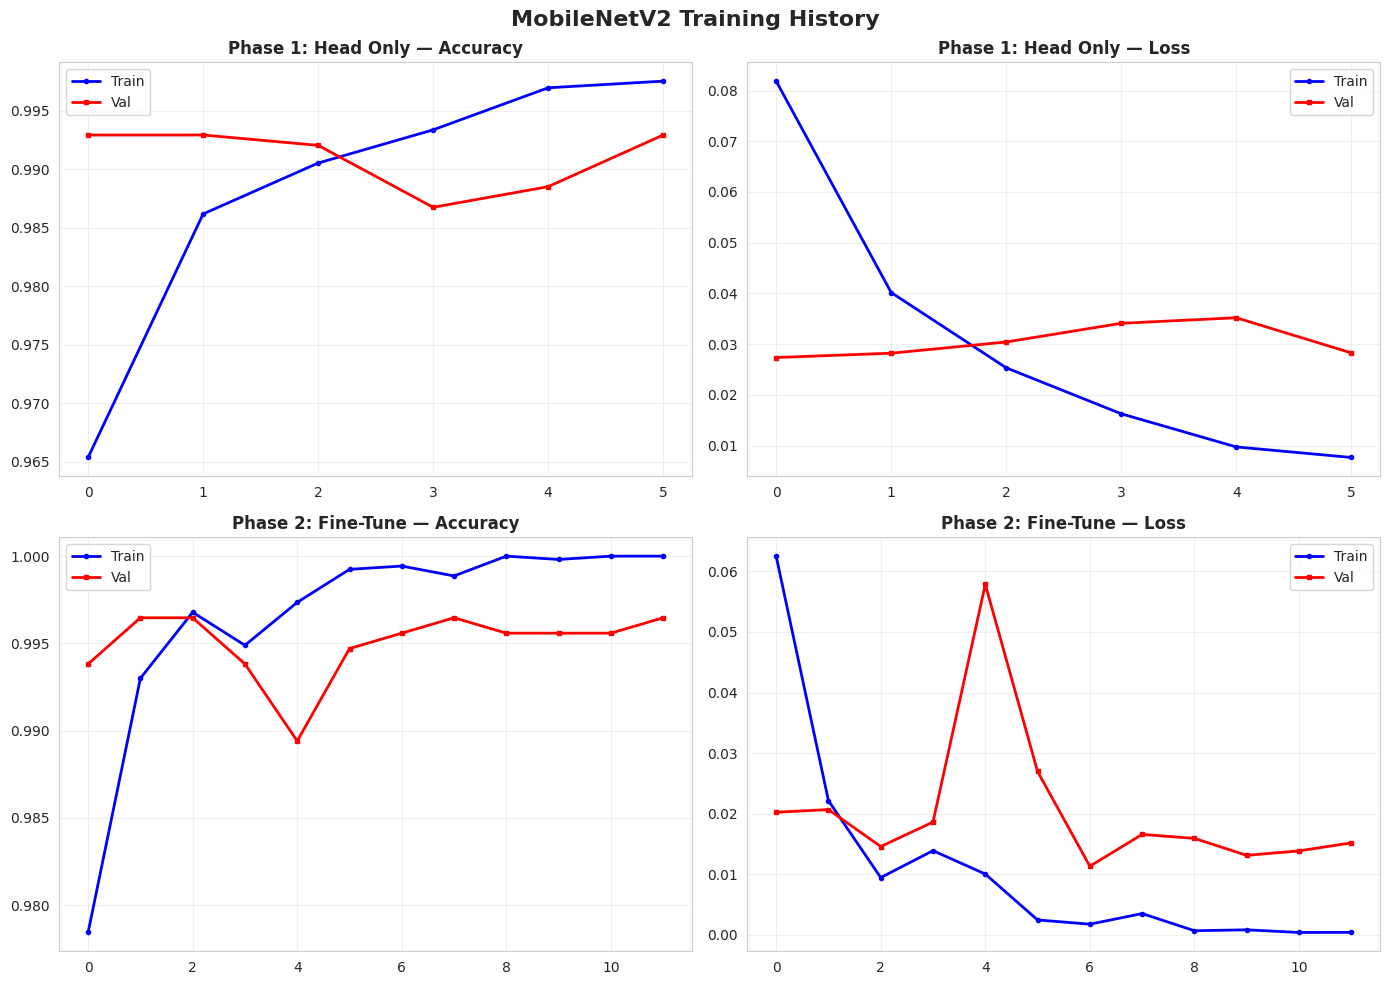

In [9]:
# ============================================================
# MobileNetV2 — Training Curves
# ============================================================
plot_history(mb_h1, mb_h2, 'MobileNetV2')

36/36 ━━━━━━━━━━━━━━━━━━━━ 11s 194ms/step

MobileNetV2 — Test Results
Accuracy: 99.74% | Precision: 0.9964 | Recall: 0.9982 | F1: 0.9973
              precision    recall  f1-score   support

     No Mask     0.9983    0.9965    0.9974       574
        Mask     0.9964    0.9982    0.9973       559

    accuracy                         0.9974      1133
   macro avg     0.9973    0.9974    0.9974      1133
weighted avg     0.9974    0.9974    0.9974      1133



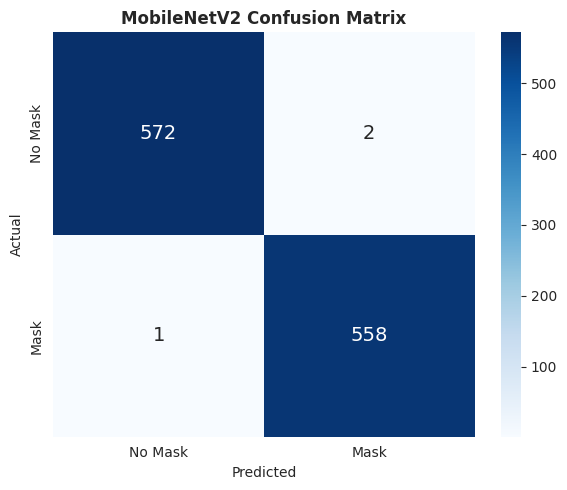


Saved: /content/drive/MyDrive/Face_Mask_Detection/models/mobilenetv2.keras (24.6 MB, 2,586,177 params)


In [10]:
# ============================================================
# MobileNetV2 — Evaluate & Save
# ============================================================
mb_results = eval_model(mobilenet_model, 'MobileNetV2')

mobilenet_model.save(mb_save)
mb_size = os.path.getsize(mb_save)/(1024**2)
mb_params = mobilenet_model.count_params()
print(f"\nSaved: {mb_save} ({mb_size:.1f} MB, {mb_params:,} params)")

In [11]:
# ============================================================
# FREE MobileNetV2 from memory before loading ResNet50
# ============================================================
del mobilenet_model, mobilenet_base, mb_h1, mb_h2
gc.collect()
tf.keras.backend.clear_session()
print("MobileNetV2 freed from memory. Ready for ResNet50.")

MobileNetV2 freed from memory. Ready for ResNet50.


---
## Model B: ResNet50

**High-capacity** (~25.6M params) with residual/skip connections.
Higher accuracy potential but larger model size.

### Phase 1: Train head only (base frozen)

In [12]:
# ============================================================
# ResNet50 — Build Model
# ============================================================
resnet_base = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
resnet_base.trainable = False

inputs = keras.Input(shape=(224,224,3))
x = resnet_base(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)
resnet_model = Model(inputs, outputs, name='ResNet50')

resnet_model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
resnet_model.summary()
print(f"\nBase frozen: {len(resnet_base.layers)} layers")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "ResNet50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,768,385 (94.48 MB)

 Trainable params: 1,180,673 (4.50 MB)

 Non-trainable params: 23,587,712 (89.98 MB)


Base frozen: 175 layers


In [13]:
# ============================================================
# ResNet50 — Phase 1 Training
# ============================================================
# Recreate generators (they were consumed)
train_gen = DataGen(X_train, y_train, BATCH_SIZE)
val_gen   = DataGen(X_val, y_val, BATCH_SIZE, shuffle=False)

print("PHASE 1: Training head only (base frozen)...\n")

rn_h1 = resnet_model.fit(
    train_gen, epochs=10, validation_data=val_gen,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
    ], verbose=1
)
print(f"\nPhase 1 done — Best val_acc: {max(rn_h1.history['val_accuracy']):.4f}")

PHASE 1: Training head only (base frozen)...

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


166/166 ━━━━━━━━━━━━━━━━━━━━ 48s 202ms/step - accuracy: 0.5353 - loss: 0.7109 - val_accuracy: 0.5790 - val_loss: 0.6770 - learning_rate: 0.0010
Epoch 2/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 18s 107ms/step - accuracy: 0.5769 - loss: 0.6735 - val_accuracy: 0.6055 - val_loss: 0.6641 - learning_rate: 0.0010
Epoch 3/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 18s 107ms/step - accuracy: 0.5964 - loss: 0.6642 - val_accuracy: 0.6169 - val_loss: 0.6567 - learning_rate: 0.0010
Epoch 4/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 18s 107ms/step - accuracy: 0.5971 - loss: 0.6579 - val_accuracy: 0.6222 - val_loss: 0.6516 - learning_rate: 0.0010
Epoch 5/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 18s 107ms/step - accuracy: 0.6096 - loss: 0.6526 - val_accuracy: 0.6434 - val_loss: 0.6374 - learning_rate: 0.0010
Epoch 6/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 18s 107ms/step - accuracy: 0.6047 - loss: 0.6546 - val_accuracy: 0.6399 - val_loss: 0.6543 - learning_rate: 0.0010
Epoch 7/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 18s 107ms/step - accuracy: 0.6128 - loss:

### Phase 2: Unfreeze top 40 layers, fine-tune with lr=0.0001

In [14]:
# ============================================================
# ResNet50 — Phase 2: Fine-tune
# ============================================================
resnet_base.trainable = True
for layer in resnet_base.layers[:-40]:
    layer.trainable = False

resnet_model.compile(optimizer=Adam(learning_rate=0.0001),
                     loss='binary_crossentropy', metrics=['accuracy'])

trainable = sum(1 for l in resnet_base.layers if l.trainable)
print(f"Unfrozen top {trainable} layers, lr=0.0001")

rn_save = os.path.join(MODEL_DIR, 'resnet50.keras')

# Recreate generators
train_gen = DataGen(X_train, y_train, BATCH_SIZE)
val_gen   = DataGen(X_val, y_val, BATCH_SIZE, shuffle=False)

print("\nPHASE 2: Fine-tuning...\n")
rn_h2 = resnet_model.fit(
    train_gen, epochs=30, validation_data=val_gen,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
        ModelCheckpoint(rn_save, monitor='val_accuracy', save_best_only=True, verbose=1)
    ], verbose=1
)
print(f"\nPhase 2 done — Best val_acc: {max(rn_h2.history['val_accuracy']):.4f}")

Unfrozen top 40 layers, lr=0.0001

PHASE 2: Fine-tuning...

Epoch 1/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.6572 - loss: 0.8940
Epoch 1: val_accuracy improved from None to 0.74492, saving model to /content/drive/MyDrive/Face_Mask_Detection/models/resnet50.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Face_Mask_Detection/models/resnet50.keras
166/166 ━━━━━━━━━━━━━━━━━━━━ 74s 282ms/step - accuracy: 0.7273 - loss: 0.5971 - val_accuracy: 0.7449 - val_loss: 0.4622 - learning_rate: 1.0000e-04
Epoch 2/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.8142 - loss: 0.4072
Epoch 2: val_accuracy did not improve from 0.74492
166/166 ━━━━━━━━━━━━━━━━━━━━ 26s 158ms/step - accuracy: 0.8250 - loss: 0.3888 - val_accuracy: 0.6849 - val_loss: 1.5990 - learning_rate: 1.0000e-04
Epoch 3/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.8392 - loss: 0.3499
Epoch 3: val_accuracy improved from 0.74492 to 0.87908, saving model to /content/drive/MyDrive/

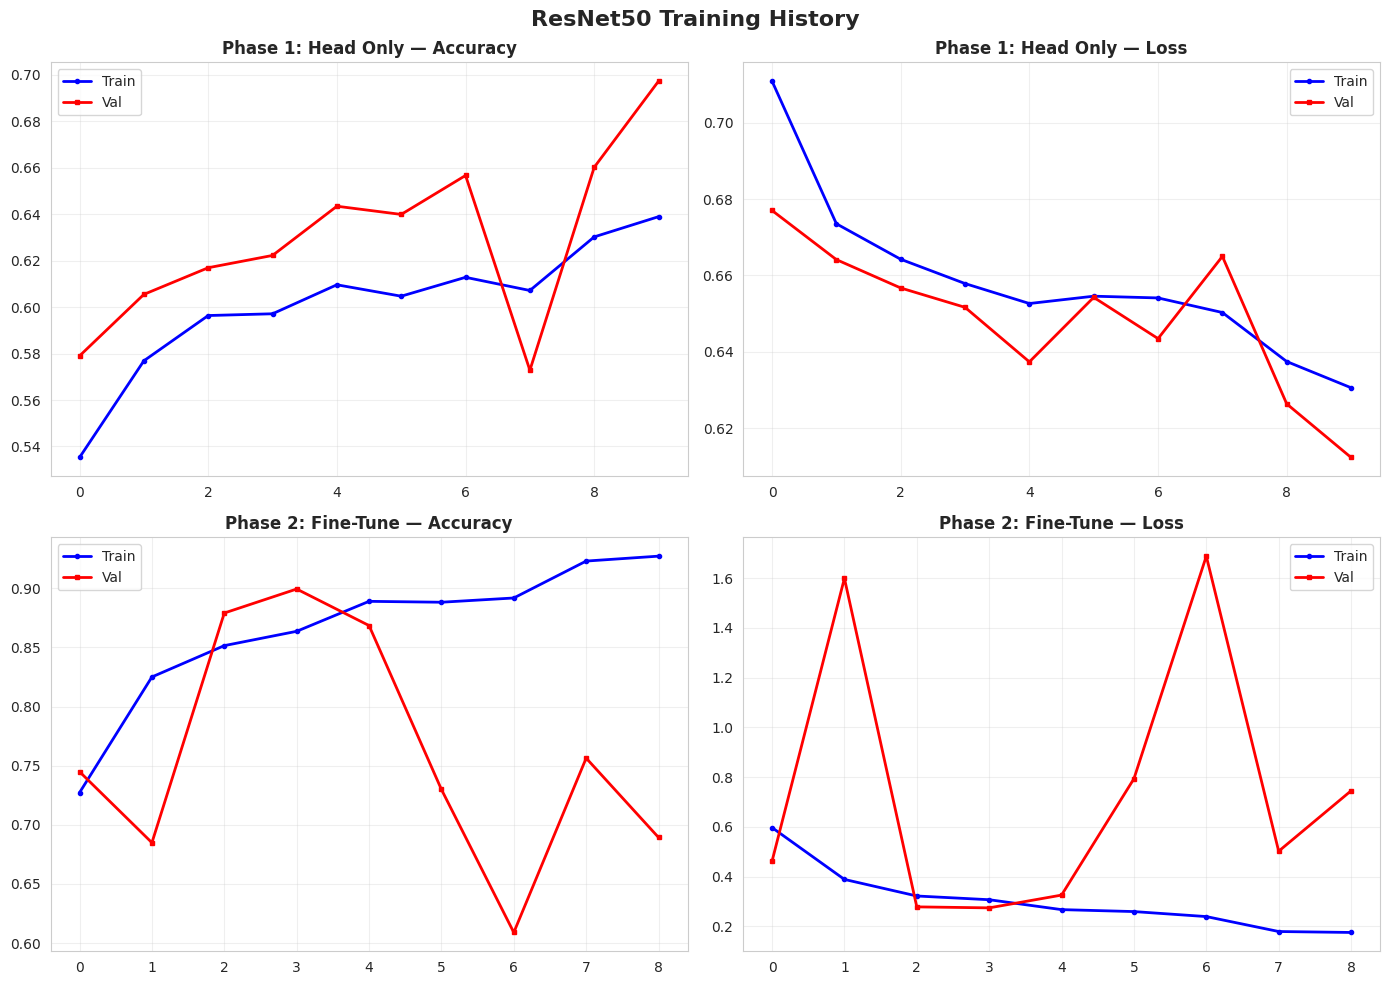

In [15]:
# ============================================================
# ResNet50 — Training Curves
# ============================================================
plot_history(rn_h1, rn_h2, 'ResNet50')

36/36 ━━━━━━━━━━━━━━━━━━━━ 12s 218ms/step

ResNet50 — Test Results
Accuracy: 88.17% | Precision: 0.8433 | Recall: 0.9338 | F1: 0.8862
              precision    recall  f1-score   support

     No Mask     0.9280    0.8310    0.8768       574
        Mask     0.8433    0.9338    0.8862       559

    accuracy                         0.8817      1133
   macro avg     0.8857    0.8824    0.8815      1133
weighted avg     0.8862    0.8817    0.8815      1133



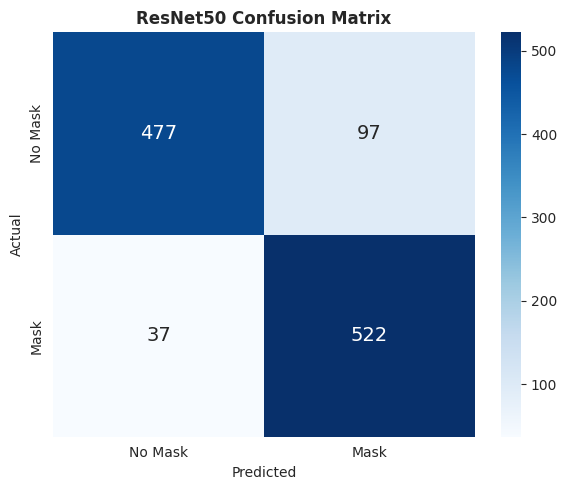


Saved: /content/drive/MyDrive/Face_Mask_Detection/models/resnet50.keras (225.0 MB, 24,768,385 params)


In [16]:
# ============================================================
# ResNet50 — Evaluate & Save
# ============================================================
rn_results = eval_model(resnet_model, 'ResNet50')

resnet_model.save(rn_save)
rn_size = os.path.getsize(rn_save)/(1024**2)
rn_params = resnet_model.count_params()
print(f"\nSaved: {rn_save} ({rn_size:.1f} MB, {rn_params:,} params)")

---
## 4. Model Comparison — All 3 Models

36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step

Custom CNN — Test Results
Accuracy: 96.82% | Precision: 0.9580 | Recall: 0.9785 | F1: 0.9681
              precision    recall  f1-score   support

     No Mask     0.9786    0.9582    0.9683       574
        Mask     0.9580    0.9785    0.9681       559

    accuracy                         0.9682      1133
   macro avg     0.9683    0.9684    0.9682      1133
weighted avg     0.9684    0.9682    0.9682      1133



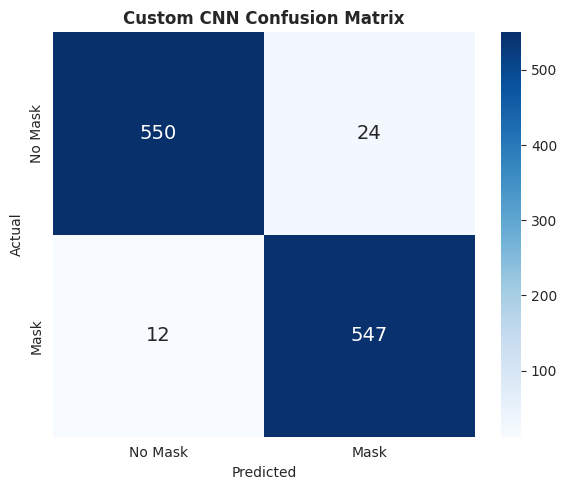

In [17]:
# ============================================================
# Load Custom CNN for comparison
# ============================================================
cnn_path = os.path.join(MODEL_DIR, 'custom_cnn.keras')
cnn_loaded = False
cnn_results = {'accuracy': None, 'precision': None, 'recall': None, 'f1': None}
cnn_params, cnn_size = None, None

try:
    cnn_model = keras.models.load_model(cnn_path)
    cnn_results = eval_model(cnn_model, 'Custom CNN')
    cnn_params = cnn_model.count_params()
    cnn_size = os.path.getsize(cnn_path)/(1024**2)
    cnn_loaded = True
    del cnn_model; gc.collect()
except Exception as e:
    print(f"Could not load Custom CNN: {e}")
    print("Comparing MobileNetV2 and ResNet50 only.")

In [18]:
# ============================================================
# Comparison Table
# ============================================================
rows = []
if cnn_loaded:
    rows.append(['Custom CNN', f"{cnn_results['accuracy']*100:.2f}%",
                 f"{cnn_results['precision']:.4f}", f"{cnn_results['recall']:.4f}",
                 f"{cnn_results['f1']:.4f}", f"{cnn_params:,}", f"{cnn_size:.1f}"])

rows.append(['MobileNetV2', f"{mb_results['accuracy']*100:.2f}%",
             f"{mb_results['precision']:.4f}", f"{mb_results['recall']:.4f}",
             f"{mb_results['f1']:.4f}", f"{mb_params:,}", f"{mb_size:.1f}"])

rows.append(['ResNet50', f"{rn_results['accuracy']*100:.2f}%",
             f"{rn_results['precision']:.4f}", f"{rn_results['recall']:.4f}",
             f"{rn_results['f1']:.4f}", f"{rn_params:,}", f"{rn_size:.1f}"])

df = pd.DataFrame(rows, columns=['Model','Accuracy','Precision','Recall','F1-Score','Params','Size (MB)'])
df = df.set_index('Model')
print("\n" + "=" * 80)
print("MODEL COMPARISON")
print("=" * 80)
print(df.to_string())
df


MODEL COMPARISON
            Accuracy Precision  Recall F1-Score      Params Size (MB)
Model                                                                
Custom CNN    96.82%    0.9580  0.9785   0.9681     490,689       5.7
MobileNetV2   99.74%    0.9964  0.9982   0.9973   2,586,177      24.6
ResNet50      88.17%    0.8433  0.9338   0.8862  24,768,385     225.0


,Accuracy,Precision,Recall,F1-Score,Params,Size (MB)
Model,,,,,,
Custom CNN,96.82%,0.9580,0.9785,0.9681,"490,689",5.7
MobileNetV2,99.74%,0.9964,0.9982,0.9973,"2,586,177",24.6
ResNet50,88.17%,0.8433,0.9338,0.8862,"24,768,385",225.0


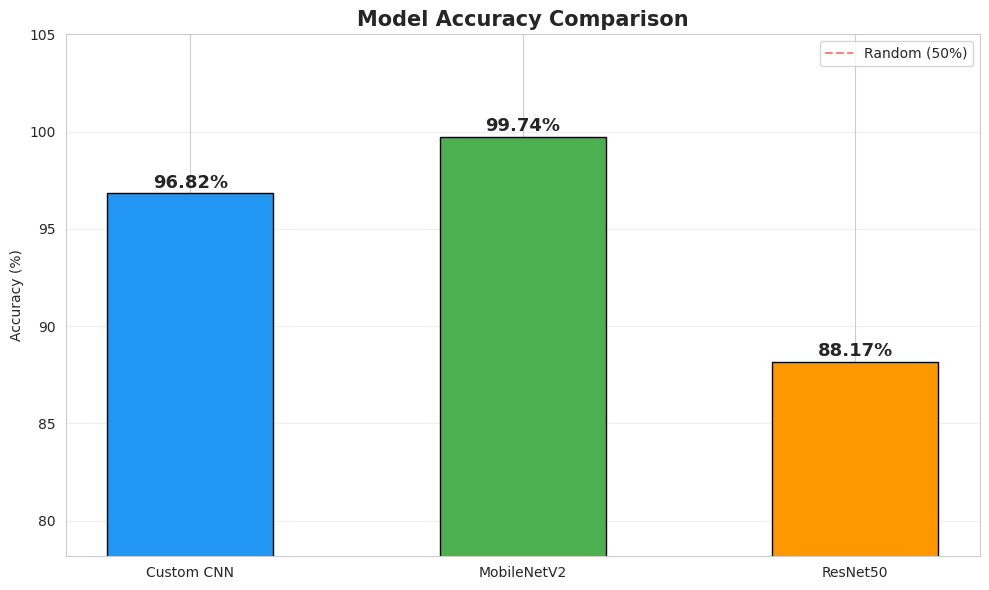

In [19]:
# ============================================================
# Accuracy Bar Chart
# ============================================================
names, accs, colors = [], [], []
if cnn_loaded:
    names.append('Custom CNN'); accs.append(cnn_results['accuracy']*100); colors.append('#2196F3')
names += ['MobileNetV2', 'ResNet50']
accs += [mb_results['accuracy']*100, rn_results['accuracy']*100]
colors += ['#4CAF50', '#FF9800']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(names, accs, color=colors, edgecolor='black', width=0.5)
for bar, a in zip(bars, accs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{a:.2f}%', ha='center', fontweight='bold', fontsize=13)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Model Accuracy Comparison', fontsize=15, fontweight='bold')
ax.set_ylim([min(accs)-10, 105])
ax.axhline(y=50, color='red', ls='--', alpha=0.5, label='Random (50%)')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

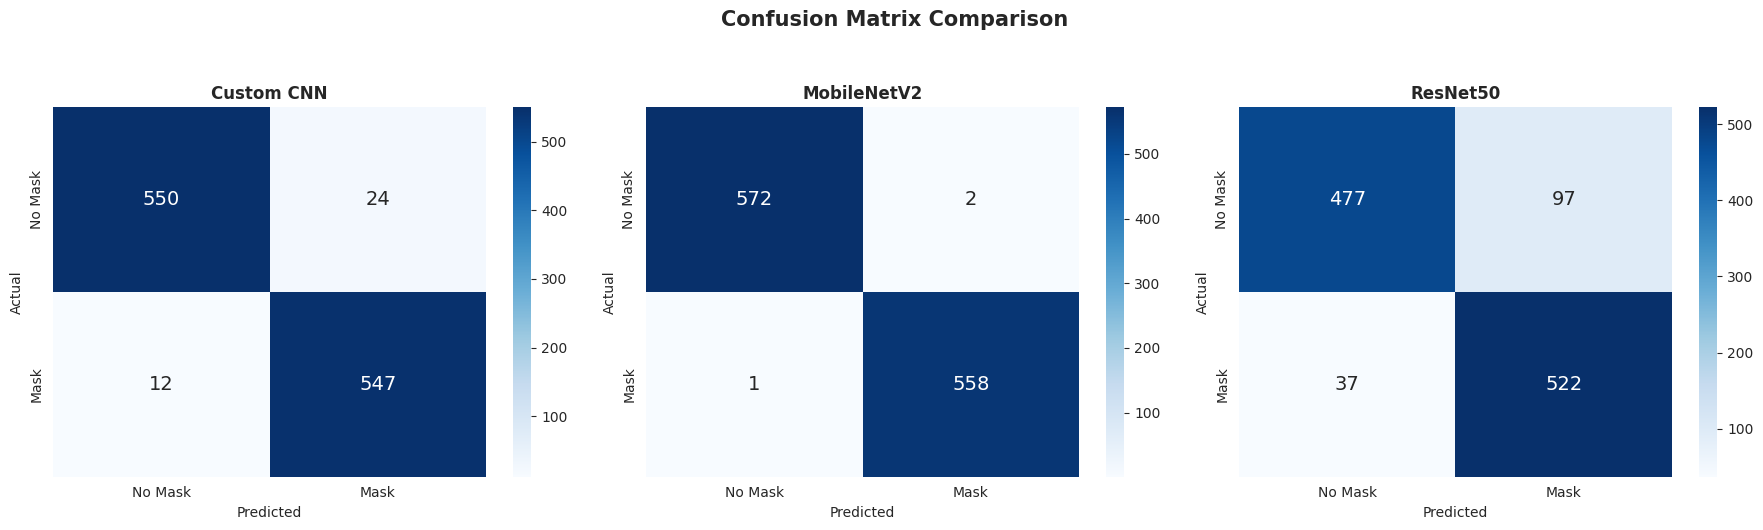

In [20]:
# ============================================================
# Side-by-Side Confusion Matrices
# ============================================================
cm_list = []
if cnn_loaded: cm_list.append((cnn_results['cm'], 'Custom CNN'))
cm_list.append((mb_results['cm'], 'MobileNetV2'))
cm_list.append((rn_results['cm'], 'ResNet50'))

fig, axes = plt.subplots(1, len(cm_list), figsize=(6*len(cm_list), 5))
if len(cm_list) == 1: axes = [axes]

for ax, (cm, name) in zip(axes, cm_list):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                annot_kws={'size':14}, ax=ax)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrix Comparison', fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout(); plt.show()

In [21]:
# ============================================================
# Final Summary
# ============================================================
print("=" * 60)
print("NOTEBOOK 3 COMPLETE")
print("=" * 60)
print(f"\nModels saved to Google Drive:")
print(f"  MobileNetV2: {mb_save} ({mb_size:.1f} MB)")
print(f"  ResNet50:    {rn_save} ({rn_size:.1f} MB)")
print(f"\nTest Accuracy:")
if cnn_loaded: print(f"  Custom CNN:  {cnn_results['accuracy']*100:.2f}%")
print(f"  MobileNetV2: {mb_results['accuracy']*100:.2f}%")
print(f"  ResNet50:    {rn_results['accuracy']*100:.2f}%")
print(f"\n✅ Next: Run Notebook 4 (Ensemble & Evaluation)")

NOTEBOOK 3 COMPLETE

Models saved to Google Drive:
  MobileNetV2: /content/drive/MyDrive/Face_Mask_Detection/models/mobilenetv2.keras (24.6 MB)
  ResNet50:    /content/drive/MyDrive/Face_Mask_Detection/models/resnet50.keras (225.0 MB)

Test Accuracy:
  Custom CNN:  96.82%
  MobileNetV2: 99.74%
  ResNet50:    88.17%

✅ Next: Run Notebook 4 (Ensemble & Evaluation)
